In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch


ROOT = Path.cwd()

for candidate in (ROOT, *ROOT.parents):
    if (candidate / "src" / "obscalib").exists():
        ROOT = candidate
        break

if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))


from kaist_dataset.dataset import KAISTCalibrationDataset, build_kaist_sequence_specs

from obscalib.calibration.state import CalibrationState
from obscalib.calibration.update import CalibrationUpdater
from obscalib.data.collation import collate_windows
from obscalib.data.device import window_batch_to
from obscalib.geometry.lie import se3_exp, se3_log
from obscalib.geometry.processing import GeometryProcessor
from obscalib.models.obs_calib_model import ObsCalibModel
from obscalib.pipeline.window_step import WindowStep
from obscalib.tokenization.tokenizer import Tokenizer
from obscalib.training.checkpoint import load_training_checkpoint, read_training_checkpoint

In [2]:
##################################################
# Checkpoint
##################################################

RUN_NAME = "kaist_hybrid_rollout_001"

CHECKPOINT_PATH = (
    ROOT
    / "runs"
    / RUN_NAME
    / "best.pt"
)


##################################################
# Compute device
##################################################

DEVICE_NAME = "cuda"

DEVICE = torch.device(
    DEVICE_NAME
)

MODEL_DTYPE = torch.float32


##################################################
# Dataset location
##################################################

KAIST_DATASET_ROOT = Path(
    "/mnt/d/Downloads/MobRobLab/KAISTDataset"
)

LIDAR_POSE_ROOT = Path(
    "/home/camel/Skoltech/phd_proposal/data/KAISTDataset"
)


##################################################
# Rollout sequence
##################################################

SEQUENCE_NAME = "Urban38"

# First dataset window used in the rollout.
ROLLOUT_START_WINDOW = 0

# None means use all remaining windows in the sequence.
ROLLOUT_NUM_WINDOWS = None


##################################################
# Initial calibration error
##################################################
#
# delta_xi follows:
#
#     [phi_x, phi_y, phi_z, rho_x, rho_y, rho_z]
#
# and is applied with the same left perturbation used during training:
#
#     T_initial = Exp(delta_xi) @ T_true
#
# rho is an SE3 tangent component, not directly the transform translation column.
##################################################

INITIAL_DELTA_XI = {
    "imu": np.array([
        np.deg2rad(8.0),
        np.deg2rad(-6.0),
        np.deg2rad(5.0),
        0.08,
        -0.05,
        0.04,
    ]),

    "lidar": np.array([
        np.deg2rad(-8.0),
        np.deg2rad(6.0),
        np.deg2rad(-5.0),
        -0.08,
        0.05,
        -0.04,
    ]),
}


INITIAL_DELTA_TAU_S = {
    "imu": 0.020,
    "lidar": -0.020,
}

In [3]:
checkpoint_data = read_training_checkpoint(
    CHECKPOINT_PATH,
    map_location="cpu",
)


experiment = (
    checkpoint_data
    .get("extra_state", {})
    .get("experiment")
)


if experiment is None:
    raise ValueError(
        "This checkpoint does not contain an experiment snapshot. "
        "Attach EXPERIMENT_SNAPSHOT using the training notebook first."
    )


model_config = experiment[
    "model_config"
]

windowing_config = experiment[
    "windowing_config"
]

rig_calibration = experiment[
    "rig_calibration"
]

measurement_dim = experiment[
    "measurement_dim"
]


print("Checkpoint:", CHECKPOINT_PATH)
print("Checkpoint epoch:", checkpoint_data.get("epoch"))
print("Sequence split:", experiment["sequence_split"])
print()
print("Model configuration:")
print(model_config)
print()
print("Window configuration:")
print(windowing_config)

Checkpoint: /home/camel/Skoltech/Mobile_Robotics_Lab/nn-obs-calib/runs/kaist_hybrid_rollout_001/best.pt
Checkpoint epoch: 43
Sequence split: {'train': ('Urban08', 'Urban12', 'Urban13', 'Urban14', 'Urban15', 'Urban16'), 'validation': ('Urban26', 'Urban28'), 'test': ('Urban38', 'Urban39')}

Model configuration:
ObsCalibModelConfig(transformer=TransformerConfig(input_dim=8, d_model=128, n_heads=8, num_layers=12, dim_feedforward=512, dropout=0.1, num_summary_tokens=4, activation='gelu'), mlp=MLPConfig(hidden_dims=(256, 128), output_dim=128, activation='gelu', dropout=0.1), calibration_head=CalibrationHeadConfig(calibration_context_dim=7, hidden_dims=(128, 64), activation='gelu', dropout=0.1), head_keys=('imu', 'lidar'))

Window configuration:
WindowingConfig(window_duration_s=5.0, window_stride_s=5.0, max_samples_per_sensor=700)


In [4]:
sequence_split = experiment[
    "sequence_split"
]


if SEQUENCE_NAME in sequence_split["train"]:
    print(
        f"WARNING: {SEQUENCE_NAME} belongs to the training split."
    )

elif SEQUENCE_NAME in sequence_split["validation"]:
    print(
        f"{SEQUENCE_NAME} belongs to the validation split."
    )

elif SEQUENCE_NAME in sequence_split["test"]:
    print(
        f"{SEQUENCE_NAME} belongs to the held-out test split."
    )

else:
    print(
        f"{SEQUENCE_NAME} was not part of the recorded experiment split."
    )

Urban38 belongs to the held-out test split.


In [5]:
sequence_spec = build_kaist_sequence_specs(
    sequence_names=[
        SEQUENCE_NAME,
    ],
    kaist_dataset_root=KAIST_DATASET_ROOT,
    lidar_pose_root=LIDAR_POSE_ROOT,
)[0]


rollout_dataset = KAISTCalibrationDataset(
    [
        sequence_spec,
    ],
    rig_calibration,
    windowing_config,
    measurement_dtype=torch.float32,
    source_timestamp_dtype=torch.float64,
    window_timestamp_dtype=torch.float32,
)


print(
    rollout_dataset.summary()
)

KAISTCalibrationDataset: 354 windows from 1 sequences
approximate tensor storage: 6.6 MiB
  Urban38: windows=354, duration=2147.3s, IMU=216225, LiDAR=17005


In [6]:
model = ObsCalibModel(
    model_config
).to(
    device=DEVICE,
    dtype=MODEL_DTYPE,
)


load_training_checkpoint(
    CHECKPOINT_PATH,
    model=model,
    map_location=DEVICE,
    restore_rng_state=False,
)


model.eval()


geometry_processor = GeometryProcessor()

tokenizer = Tokenizer(
    measurement_dim=measurement_dim,
)

calibration_updater = CalibrationUpdater()


window_step = WindowStep(
    geometry_processor=geometry_processor,
    tokenizer=tokenizer,
    model=model,
    calibration_updater=calibration_updater,
    observability_estimator=None,
    observability_mapper=None,
)


print(
    "Parameters:",
    sum(
        parameter.numel()
        for parameter in model.parameters()
    ),
)

Parameters: 2614162


In [7]:
num_available_windows = len(
    rollout_dataset
)


rollout_end_window = (
    num_available_windows
    if ROLLOUT_NUM_WINDOWS is None
    else min(
        ROLLOUT_START_WINDOW
        + ROLLOUT_NUM_WINDOWS,
        num_available_windows,
    )
)


rollout_indices = list(
    range(
        ROLLOUT_START_WINDOW,
        rollout_end_window,
    )
)


if not rollout_indices:
    raise ValueError(
        "The selected rollout contains no windows."
    )


print(
    "Rollout windows:",
    len(rollout_indices),
)

print(
    "Window range:",
    rollout_indices[0],
    "...",
    rollout_indices[-1],
)

print(
    "Approximate rollout duration [s]:",
    len(rollout_indices)
    * windowing_config.window_stride_s,
)

Rollout windows: 354
Window range: 0 ... 353
Approximate rollout duration [s]: 1770.0


In [8]:
first_window = collate_windows(
    [
        rollout_dataset[
            rollout_indices[0]
        ]
    ]
)


first_window = window_batch_to(
    first_window,
    DEVICE,
    dtype=MODEL_DTYPE,
)


true_calibration = {
    calibration_key: CalibrationState(
        transform=state.transform.clone(),
        time_offset=state.time_offset.clone(),
    )
    for calibration_key, state
    in first_window.current_calibration.items()
}


initial_calibration = {}


for calibration_key, true_state in true_calibration.items():
    delta_xi = torch.as_tensor(
        INITIAL_DELTA_XI[
            calibration_key
        ],
        dtype=MODEL_DTYPE,
        device=DEVICE,
    ).reshape(
        1,
        6,
    )

    delta_tau = torch.tensor(
        [[
            INITIAL_DELTA_TAU_S[
                calibration_key
            ]
        ]],
        dtype=MODEL_DTYPE,
        device=DEVICE,
    )

    initial_calibration[
        calibration_key
    ] = CalibrationState(
        transform=(
            se3_exp(
                delta_xi
            )
            @ true_state.transform
        ),
        time_offset=(
            true_state.time_offset
            + delta_tau
        ),
    )

In [9]:
def calibration_state_error(
    estimate: CalibrationState,
    reference: CalibrationState,
):
    """Return the correction required to move estimate to reference."""

    error_transform = (
        reference.transform
        @ torch.linalg.inv(
            estimate.transform
        )
    )

    error_xi = se3_log(
        error_transform
    )

    error_tau = (
        reference.time_offset
        - estimate.time_offset
    )

    return (
        error_xi,
        error_tau,
    )

In [11]:
rollout_history = {
    calibration_key: {
        "error_before_xi": [],
        "error_after_xi": [],
        "error_before_tau": [],
        "error_after_tau": [],
        "predicted_delta_xi": [],
        "predicted_delta_tau": [],
        "event_probability": [],
        "change_time": [],
    }
    for calibration_key
    in model_config.head_keys
}


calibration = {
    calibration_key: CalibrationState(
        transform=state.transform.clone(),
        time_offset=state.time_offset.clone(),
    )
    for calibration_key, state
    in initial_calibration.items()
}


model.eval()


with torch.no_grad():
    for rollout_step, dataset_index in enumerate(
        rollout_indices
    ):
        ##################################################
        # Load the next real physical window
        ##################################################

        window = collate_windows(
            [
                rollout_dataset[
                    dataset_index
                ]
            ]
        )

        window = window_batch_to(
            window,
            DEVICE,
            dtype=MODEL_DTYPE,
        )

        ##################################################
        # The dataset's calibration is the fixed reference
        # calibration. The carried calibration is supplied
        # explicitly to WindowStep.
        ##################################################

        reference_calibration = (
            window.current_calibration
        )

        ##################################################
        # State error before this network update
        ##################################################

        for calibration_key in model_config.head_keys:
            error_xi, error_tau = calibration_state_error(
                calibration[
                    calibration_key
                ],
                reference_calibration[
                    calibration_key
                ],
            )

            rollout_history[
                calibration_key
            ]["error_before_xi"].append(
                error_xi[0].cpu()
            )

            rollout_history[
                calibration_key
            ]["error_before_tau"].append(
                error_tau[0].cpu()
            )

        ##################################################
        # One learned correction step
        ##################################################

        result = window_step(
            window,
            calibration=calibration,
        )

        ##################################################
        # Record predicted corrections
        ##################################################

        for calibration_key, prediction in result.model_output.predictions.items():
            rollout_history[
                calibration_key
            ]["predicted_delta_xi"].append(
                prediction.delta_xi[0].cpu()
            )

            rollout_history[
                calibration_key
            ]["predicted_delta_tau"].append(
                prediction.delta_tau[0].cpu()
            )

            rollout_history[
                calibration_key
            ]["event_probability"].append(
                torch.sigmoid(
                    prediction.change_event_logit[0]
                ).cpu()
            )

            rollout_history[
                calibration_key
            ]["change_time"].append(
                prediction.change_time[0].cpu()
            )

        ##################################################
        # Carry the model's own prediction forward
        ##################################################

        calibration = (
            result.next_calibration
        )

        ##################################################
        # State error after this network update
        ##################################################

        for calibration_key in model_config.head_keys:
            error_xi, error_tau = calibration_state_error(
                calibration[
                    calibration_key
                ],
                reference_calibration[
                    calibration_key
                ],
            )

            rollout_history[
                calibration_key
            ]["error_after_xi"].append(
                error_xi[0].cpu()
            )

            rollout_history[
                calibration_key
            ]["error_after_tau"].append(
                error_tau[0].cpu()
            )


##################################################
# Convert collected lists to arrays
##################################################

for calibration_key in rollout_history:
    for field_name in rollout_history[
        calibration_key
    ]:
        rollout_history[
            calibration_key
        ][field_name] = torch.stack(
            rollout_history[
                calibration_key
            ][field_name]
        ).numpy()

In [12]:
def plot_rollout_error_norms(
    history,
    calibration_key,
):
    result = history[
        calibration_key
    ]

    error_xi = result[
        "error_after_xi"
    ]

    error_tau = result[
        "error_after_tau"
    ][:, 0]

    times_s = (
        np.arange(
            len(error_xi)
        )
        * windowing_config.window_stride_s
    )

    rotation_error_deg = np.rad2deg(
        np.linalg.norm(
            error_xi[:, :3],
            axis=1,
        )
    )

    translation_error_cm = (
        100.0
        * np.linalg.norm(
            error_xi[:, 3:],
            axis=1,
        )
    )

    time_offset_error_ms = (
        1000.0
        * np.abs(
            error_tau
        )
    )

    initial_rotation_deg = np.rad2deg(
        np.linalg.norm(
            INITIAL_DELTA_XI[
                calibration_key
            ][:3]
        )
    )

    initial_translation_cm = (
        100.0
        * np.linalg.norm(
            INITIAL_DELTA_XI[
                calibration_key
            ][3:]
        )
    )

    initial_tau_ms = (
        1000.0
        * abs(
            INITIAL_DELTA_TAU_S[
                calibration_key
            ]
        )
    )

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(14, 9),
        sharex=True,
    )

    axes[0].plot(
        times_s,
        rotation_error_deg,
        label="rollout",
    )

    axes[0].axhline(
        initial_rotation_deg,
        linestyle="--",
        label="no-update baseline",
    )

    axes[0].set_ylabel(
        "rotation error [deg]"
    )

    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(
        times_s,
        translation_error_cm,
        label="rollout",
    )

    axes[1].axhline(
        initial_translation_cm,
        linestyle="--",
        label="no-update baseline",
    )

    axes[1].set_ylabel(
        "rho error [cm]"
    )

    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(
        times_s,
        time_offset_error_ms,
        label="rollout",
    )

    axes[2].axhline(
        initial_tau_ms,
        linestyle="--",
        label="no-update baseline",
    )

    axes[2].set_ylabel(
        "tau error [ms]"
    )

    axes[2].set_xlabel(
        "sequence time [s]"
    )

    axes[2].grid(True)
    axes[2].legend()

    fig.suptitle(
        f"{SEQUENCE_NAME}: {calibration_key} sequential rollout"
    )

    fig.tight_layout()
    plt.show()

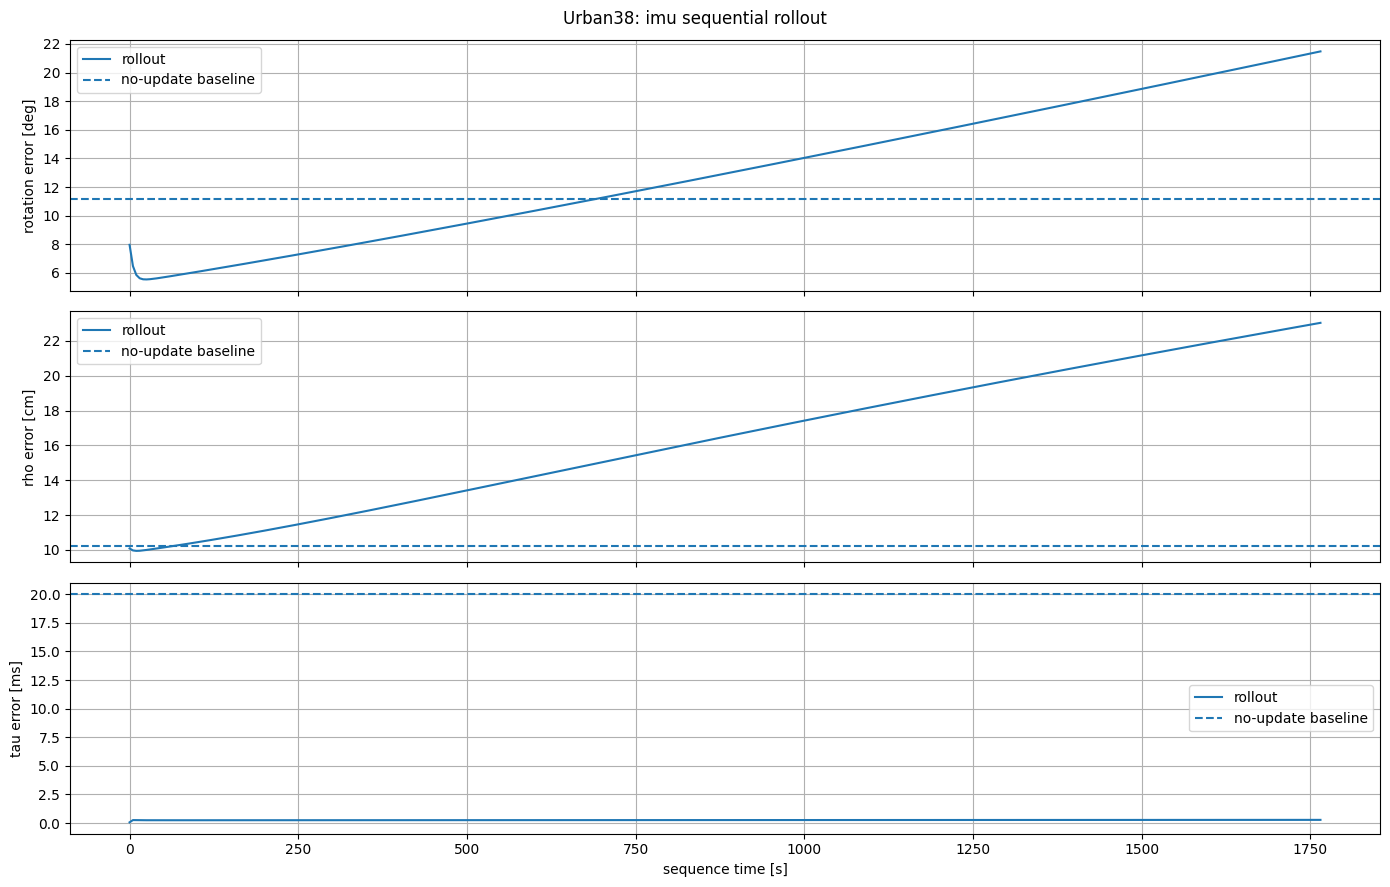

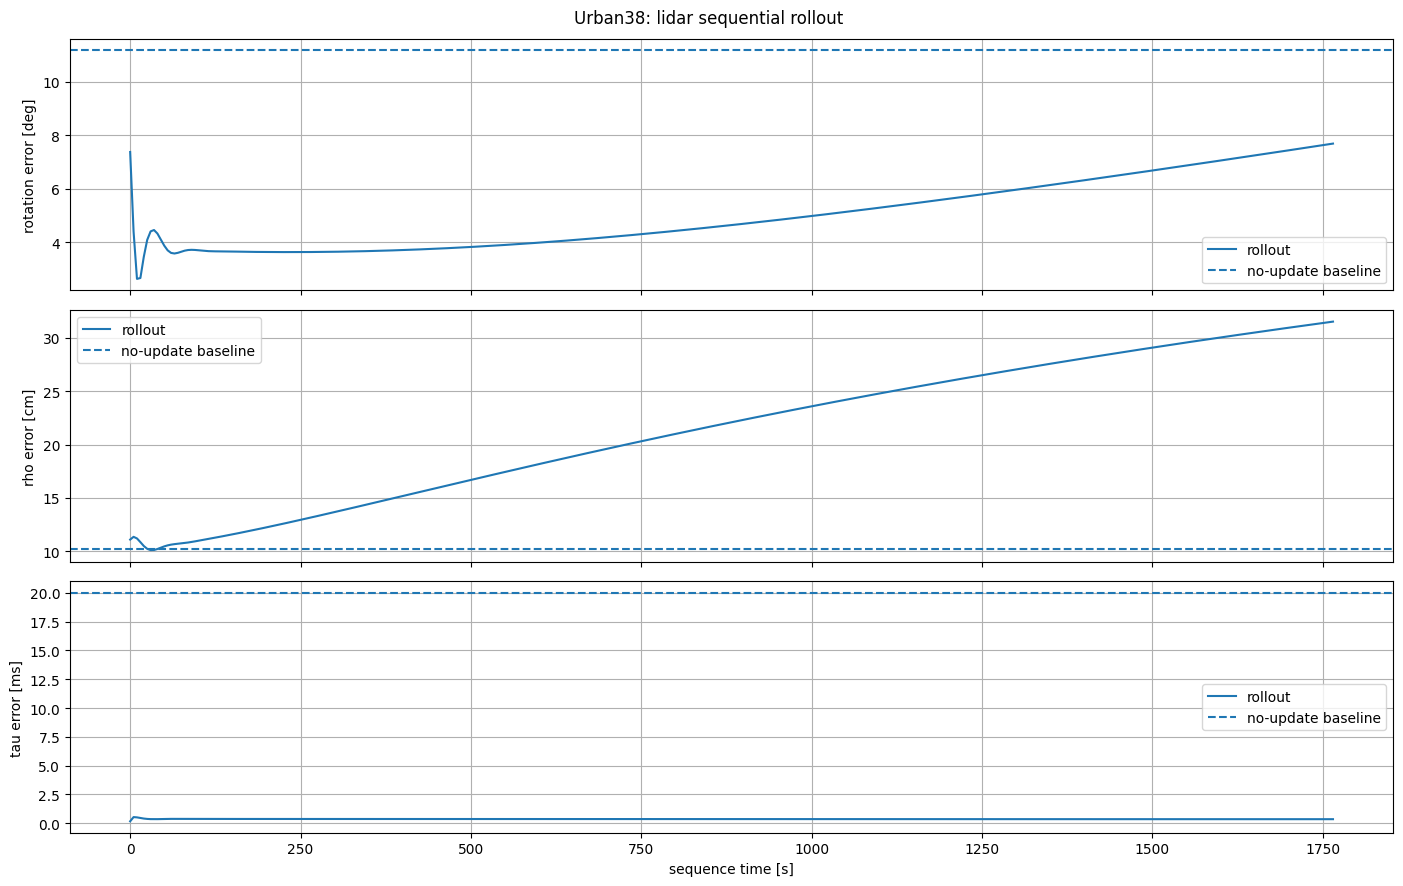

In [13]:
plot_rollout_error_norms(
    rollout_history,
    "imu",
)

plot_rollout_error_norms(
    rollout_history,
    "lidar",
)

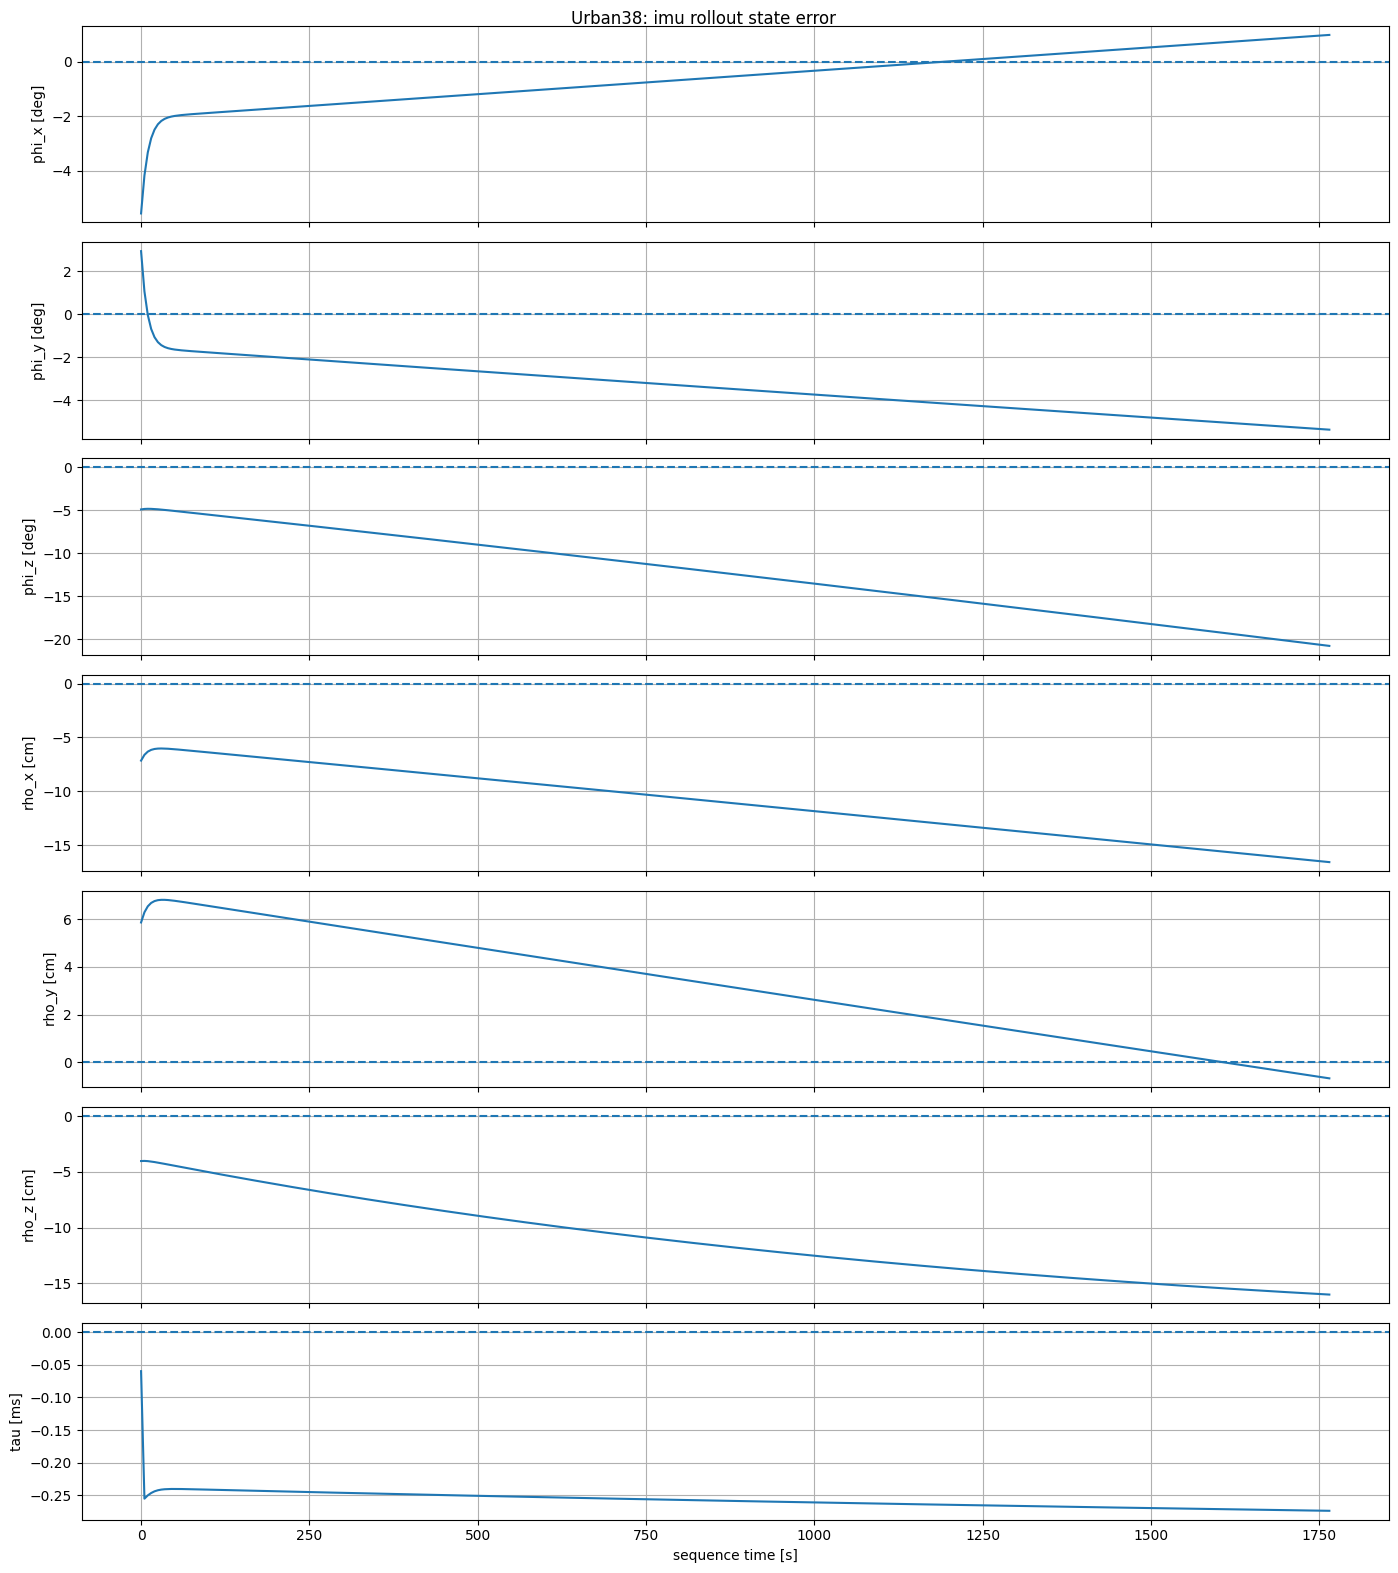

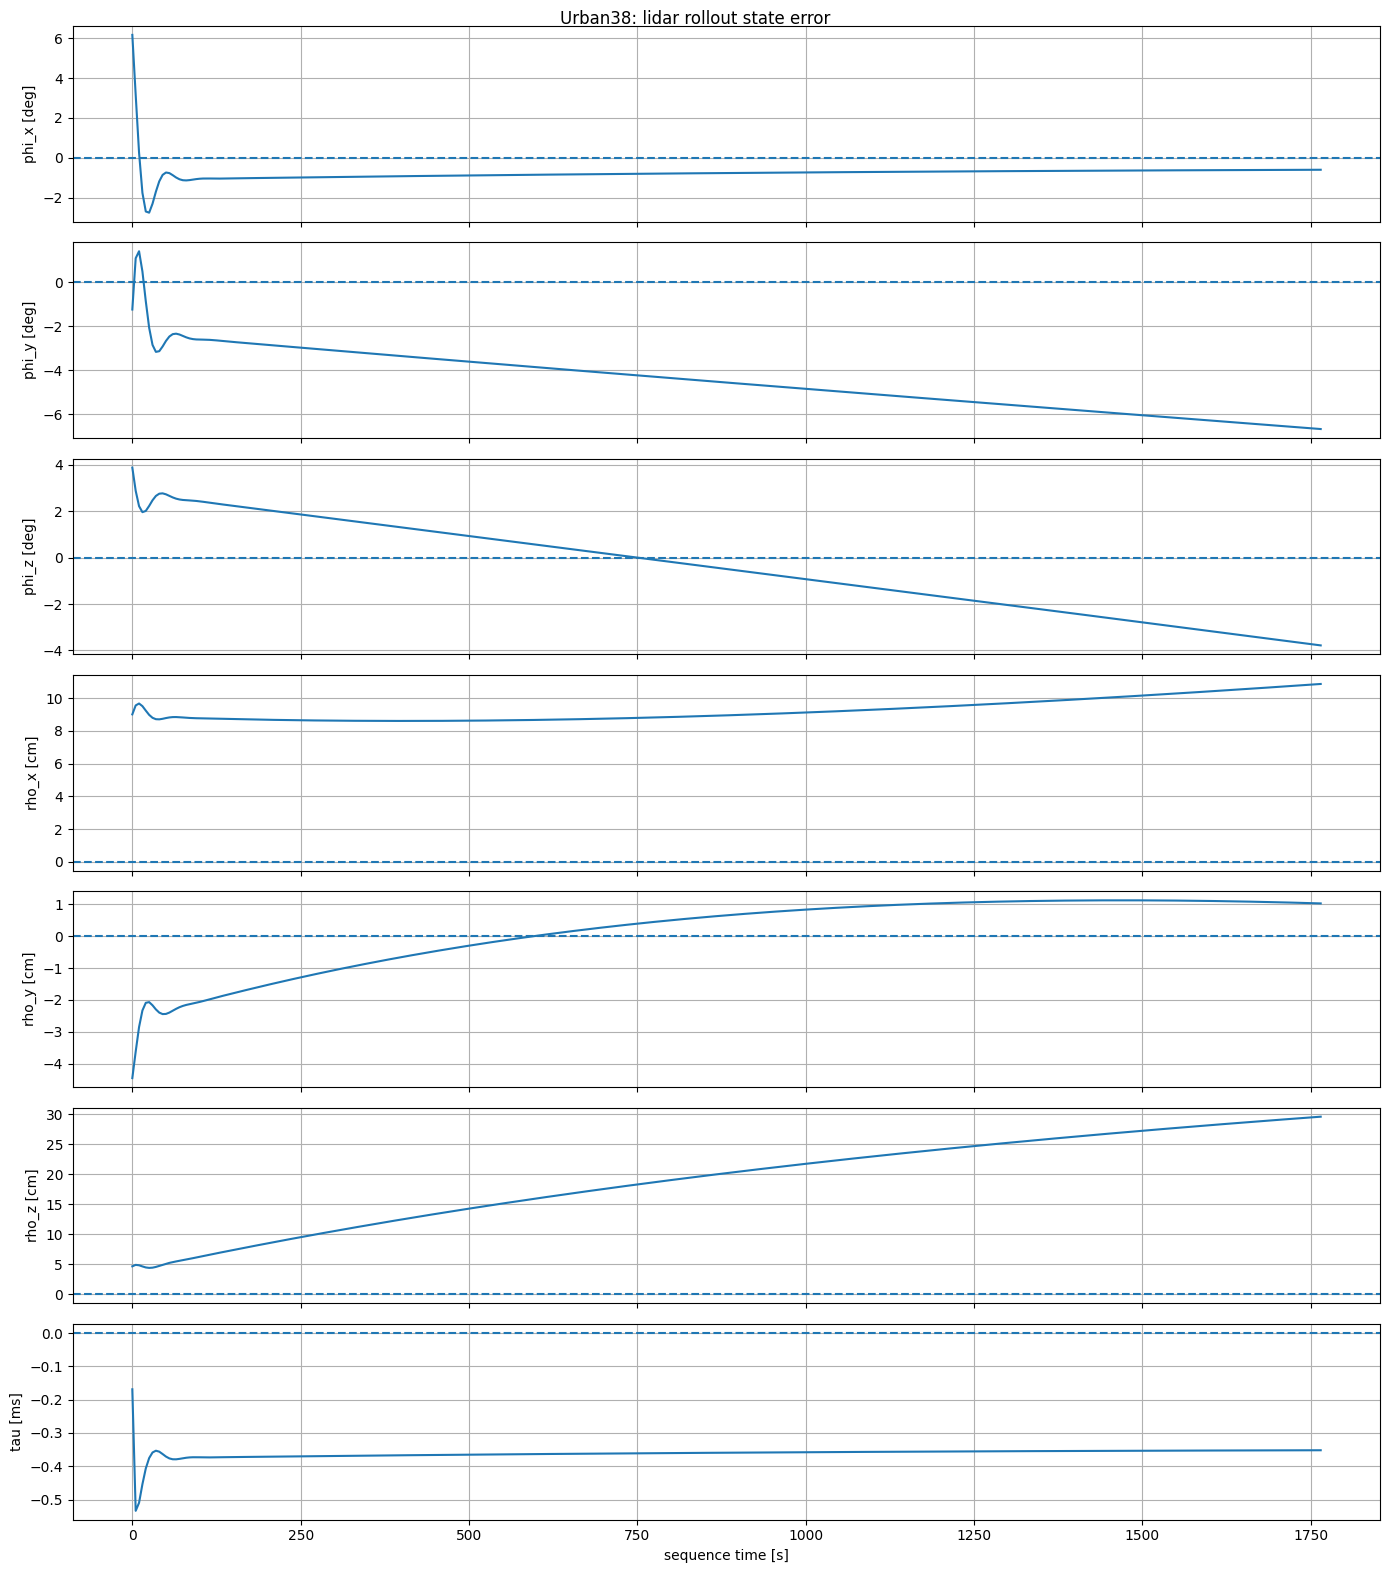

In [14]:
COMPONENT_NAMES = (
    "phi_x",
    "phi_y",
    "phi_z",
    "rho_x",
    "rho_y",
    "rho_z",
)


def plot_rollout_components(
    history,
    calibration_key,
):
    result = history[
        calibration_key
    ]

    error_xi = result[
        "error_after_xi"
    ]

    error_tau = result[
        "error_after_tau"
    ][:, 0]

    times_s = (
        np.arange(
            len(error_xi)
        )
        * windowing_config.window_stride_s
    )

    fig, axes = plt.subplots(
        7,
        1,
        figsize=(14, 16),
        sharex=True,
    )

    for component_index in range(3):
        axes[
            component_index
        ].plot(
            times_s,
            np.rad2deg(
                error_xi[
                    :,
                    component_index
                ]
            ),
        )

        axes[
            component_index
        ].axhline(
            0.0,
            linestyle="--",
        )

        axes[
            component_index
        ].set_ylabel(
            f"{COMPONENT_NAMES[component_index]} [deg]"
        )

        axes[
            component_index
        ].grid(True)

    for component_index in range(
        3,
        6,
    ):
        axes[
            component_index
        ].plot(
            times_s,
            100.0
            * error_xi[
                :,
                component_index
            ],
        )

        axes[
            component_index
        ].axhline(
            0.0,
            linestyle="--",
        )

        axes[
            component_index
        ].set_ylabel(
            f"{COMPONENT_NAMES[component_index]} [cm]"
        )

        axes[
            component_index
        ].grid(True)

    axes[-1].plot(
        times_s,
        1000.0 * error_tau,
    )

    axes[-1].axhline(
        0.0,
        linestyle="--",
    )

    axes[-1].set_ylabel(
        "tau [ms]"
    )

    axes[-1].set_xlabel(
        "sequence time [s]"
    )

    axes[-1].grid(True)

    fig.suptitle(
        f"{SEQUENCE_NAME}: {calibration_key} rollout state error"
    )

    fig.tight_layout()
    plt.show()

plot_rollout_components(
    rollout_history,
    "imu")
plot_rollout_components(
    rollout_history,
    "lidar")

In [15]:
def plot_predicted_updates(
    history,
    calibration_key,
):
    result = history[
        calibration_key
    ]

    delta_xi = result[
        "predicted_delta_xi"
    ]

    delta_tau = result[
        "predicted_delta_tau"
    ][:, 0]

    event_probability = result[
        "event_probability"
    ][:, 0]

    times_s = (
        np.arange(
            len(delta_xi)
        )
        * windowing_config.window_stride_s
    )

    rotation_update_deg = np.rad2deg(
        np.linalg.norm(
            delta_xi[:, :3],
            axis=1,
        )
    )

    translation_update_cm = (
        100.0
        * np.linalg.norm(
            delta_xi[:, 3:],
            axis=1,
        )
    )

    fig, axes = plt.subplots(
        4,
        1,
        figsize=(14, 10),
        sharex=True,
    )

    axes[0].plot(
        times_s,
        rotation_update_deg,
    )

    axes[0].set_ylabel(
        "|delta phi| [deg]"
    )

    axes[1].plot(
        times_s,
        translation_update_cm,
    )

    axes[1].set_ylabel(
        "|delta rho| [cm]"
    )

    axes[2].plot(
        times_s,
        1000.0 * delta_tau,
    )

    axes[2].set_ylabel(
        "delta tau [ms]"
    )

    axes[3].plot(
        times_s,
        event_probability,
    )

    axes[3].axhline(
        0.5,
        linestyle="--",
    )

    axes[3].set_ylabel(
        "event probability"
    )

    axes[3].set_xlabel(
        "sequence time [s]"
    )

    for axis in axes:
        axis.grid(True)

    fig.suptitle(
        f"{SEQUENCE_NAME}: {calibration_key} model updates"
    )

    fig.tight_layout()
    plt.show()

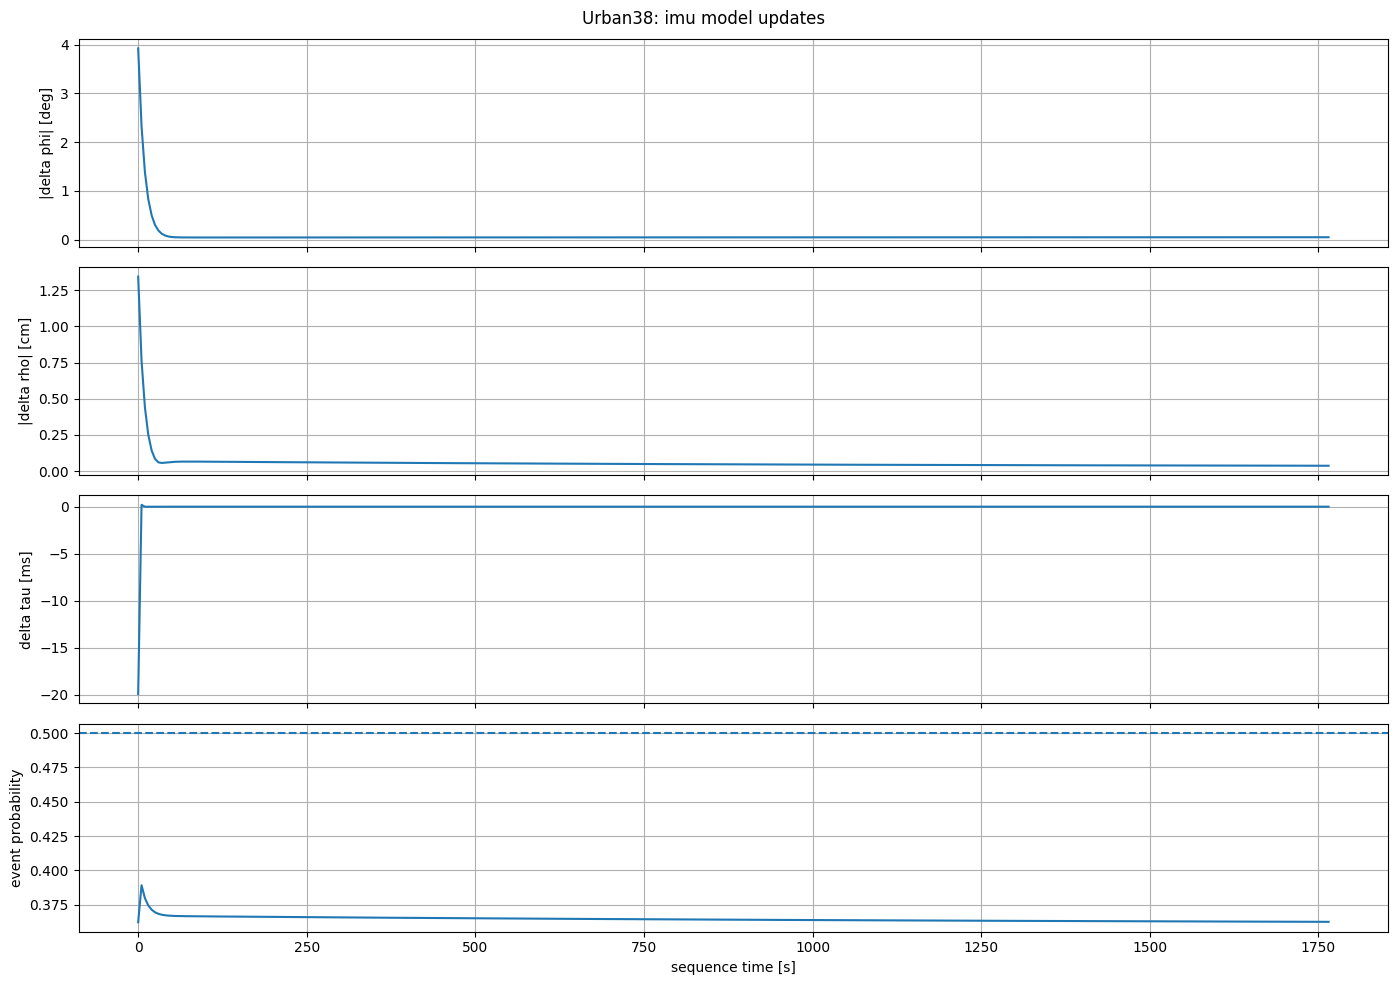

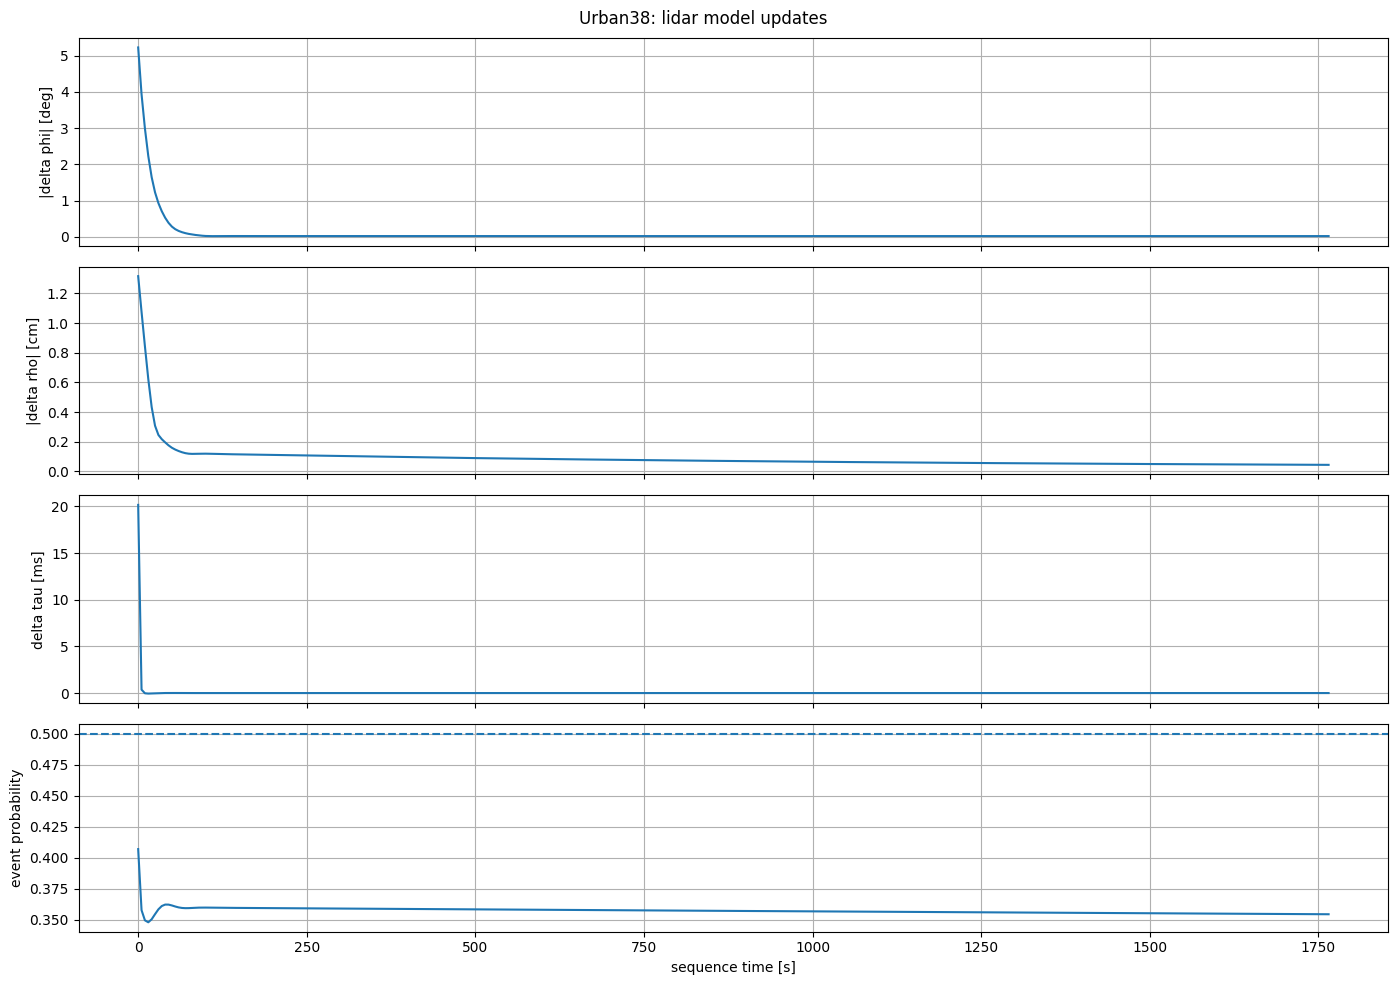

In [16]:

plot_predicted_updates(
    rollout_history,
    "imu")
plot_predicted_updates(
    rollout_history,
    "lidar")